# 03 — ML Model
### Project IceWave | Pleistocene Megafauna | WA · OR · NV

Trains a Random Forest classifier on terrain features extracted at PBDB occurrence
points vs random background points. Generates a full probability surface and ranks
candidate field targets by composite score.


In [30]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import Window
from pathlib import Path
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

Path('../data/model').mkdir(parents=True, exist_ok=True)
Path('../outputs').mkdir(parents=True, exist_ok=True)

# ── Load occurrences with terrain ─────────────────────────────────────────
occ_terrain = pd.read_csv('../data/pbdb/icewave_occurrences_with_terrain.csv')
occ_enriched = pd.read_csv('../data/merged/icewave_merged_occurrences.csv')

# Sample terrain for new iDigBio points not in original terrain CSV
new_pts = occ_enriched[
    ~occ_enriched.set_index(['latitude','longitude']).index.isin(
        occ_terrain.set_index(['latitude','longitude']).index
    )
].copy()
print(f'Original terrain points: {len(occ_terrain)}')
print(f'New points needing terrain: {len(new_pts)}')

# Sample terrain for new points
new_rows = []
with rasterio.open('../data/terrain/slope.tif') as s_src, \
     rasterio.open('../data/terrain/aspect.tif') as a_src, \
     rasterio.open('../data/terrain/ruggedness.tif') as t_src, \
     rasterio.open('../data/terrain/dem_mosaic.tif') as e_src:
    for _, row in new_pts.iterrows():
        coords = [(row.longitude, row.latitude)]
        try:
            elev  = list(e_src.sample(coords))[0][0]
            slope = list(s_src.sample(coords))[0][0]
            asp   = list(a_src.sample(coords))[0][0]
            tri   = list(t_src.sample(coords))[0][0]
            if elev > -500:
                new_rows.append({**row, 'elevation': elev,
                                 'slope': slope, 'aspect': asp, 'tri': tri})
        except:
            pass

new_terrain_df = pd.DataFrame(new_rows)
print(f'New points with valid terrain: {len(new_terrain_df)}')

# Merge all together
occ_terrain['lith_score'] = occ_terrain.merge(
    occ_enriched[['latitude','longitude','lith_score']].round(4),
    on=['latitude','longitude'], how='left'
)['lith_score'].fillna(0.5).values

occ = pd.concat([occ_terrain, new_terrain_df], ignore_index=True)
occ = occ.dropna(subset=['elevation','slope','aspect','tri'])
occ['lith_score'] = occ['lith_score'].fillna(0.5)

print(f'\nTotal occurrence points with terrain: {len(occ)}')
print(occ[['elevation','slope','aspect','tri','lith_score']].describe().round(2).to_string()))

# Drop rows with missing terrain values
occ = occ.dropna(subset=['elevation','slope','aspect','tri'])
print(f'Occurrence points with terrain: {len(occ)}')
print(f'\nTerrain stats at fossil sites:')
print(occ[['elevation','slope','aspect','tri']].describe().round(2).to_string())


SyntaxError: unmatched ')' (4145464757.py, line 60)

In [2]:
# ── Generate background points ────────────────────────────────────────────
# Random points across study area — 10:1 ratio to positives
# Sampled from valid DEM pixels only

N_BACKGROUND = len(occ) * 10
print(f'Generating {N_BACKGROUND} background points...')

with rasterio.open('../data/terrain/dem_mosaic.tif') as src:
    bounds = src.bounds
    crs    = src.crs
    
    # Random lon/lat within study area bounds
    np.random.seed(42)
    bg_lons = np.random.uniform(bounds.left,  bounds.right,  N_BACKGROUND * 3)
    bg_lats = np.random.uniform(bounds.bottom, bounds.top,   N_BACKGROUND * 3)
    
    # Sample elevation to filter out nodata (ocean, outside DEM)
    coords = list(zip(bg_lons, bg_lats))
    elev_vals = np.array([v[0] for v in src.sample(coords)])

valid_mask = (elev_vals > -500) & (elev_vals < 5000) & (~np.isnan(elev_vals))
bg_lons = bg_lons[valid_mask][:N_BACKGROUND]
bg_lats = bg_lats[valid_mask][:N_BACKGROUND]

print(f'Valid background points: {len(bg_lons)}')

bg_df = pd.DataFrame({'longitude': bg_lons, 'latitude': bg_lats})


Generating 780 background points...
Valid background points: 454


In [3]:
# ── Sample terrain at background points ───────────────────────────────────
terrain_layers = {
    'elevation': '../data/terrain/elevation.tif',
    'slope':     '../data/terrain/slope.tif',
    'aspect':    '../data/terrain/aspect.tif',
    'tri':       '../data/terrain/ruggedness.tif',
}

for col, path in terrain_layers.items():
    with rasterio.open(path) as src:
        coords = [(row.longitude, row.latitude) for _, row in bg_df.iterrows()]
        vals = [v[0] for v in src.sample(coords)]
        bg_df[col] = vals

bg_df = bg_df.replace(-9999, np.nan).dropna(subset=['elevation','slope','aspect','tri'])
bg_df = bg_df[bg_df['elevation'] > -500]
print(f'Background points after terrain sampling: {len(bg_df)}')


Background points after terrain sampling: 454


In [4]:
# ── Build training dataset ────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import joblib

FEATURES = ['elevation', 'slope', 'aspect', 'tri']

# Positives
pos = occ[FEATURES].copy()
pos['label'] = 1

# Background
neg = bg_df[FEATURES].copy()
neg['label'] = 0

# Combine
train_df = pd.concat([pos, neg], ignore_index=True).dropna()
X = train_df[FEATURES].values
y = train_df['label'].values

print(f'Training set: {y.sum()} positives, {(y==0).sum()} background')
print(f'Features: {FEATURES}')


Training set: 78 positives, 454 background
Features: ['elevation', 'slope', 'aspect', 'tri']


In [5]:
# ── Cross-validation ──────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'Cross-validation AUC scores: {auc_scores.round(3)}')
print(f'Mean AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}')


Cross-validation AUC scores: [0.907 0.778 0.868 0.781 0.929]
Mean AUC: 0.853 ± 0.063


In [6]:
# ── Train final model ─────────────────────────────────────────────────────
rf.fit(X, y)

# Feature importance
importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print('Feature importances:')
print(importance_df.to_string(index=False))

# Save model
joblib.dump(rf, '../data/model/icewave_rf_model.joblib')
print('\nModel saved: data/model/icewave_rf_model.joblib')


Feature importances:
  feature  importance
elevation    0.345601
      tri    0.270733
    slope    0.196870
   aspect    0.186796

Model saved: data/model/icewave_rf_model.joblib


In [7]:
# ── Generate prediction surface ───────────────────────────────────────────
# Process in chunks to handle large raster

print('Generating prediction surface...')

with rasterio.open('../data/terrain/slope.tif') as src:
    meta = src.meta.copy()
    meta.update(dtype='float32', compress='lzw')
    H, W = src.height, src.width
    transform = src.transform

pred_path = '../data/model/prediction_surface.tif'
CHUNK = 500

with rasterio.open('../data/terrain/elevation.tif') as elev_src,      rasterio.open('../data/terrain/slope.tif')     as slope_src,      rasterio.open('../data/terrain/aspect.tif')    as asp_src,      rasterio.open('../data/terrain/ruggedness.tif') as tri_src,      rasterio.open(pred_path, 'w', **meta)          as dst:

    for row_start in range(0, H, CHUNK):
        row_end = min(row_start + CHUNK, H)
        win = Window(0, row_start, W, row_end - row_start)

        elev  = elev_src.read(1,  window=win).astype(float)
        slope = slope_src.read(1, window=win).astype(float)
        asp   = asp_src.read(1,   window=win).astype(float)
        tri   = tri_src.read(1,   window=win).astype(float)

        rows, cols = elev.shape
        chunk_df = pd.DataFrame({
            'elevation': elev.ravel(),
            'slope':     slope.ravel(),
            'aspect':    asp.ravel(),
            'tri':       tri.ravel(),
        })

        valid_mask = (
            (chunk_df['elevation'] > -500) &
            (chunk_df['slope']     >= 0) &
            (chunk_df['tri']       >= 0) &
            chunk_df[FEATURES].notna().all(axis=1)
        )

        probs = np.zeros(len(chunk_df), dtype='float32')
        if valid_mask.sum() > 0:
            probs[valid_mask] = rf.predict_proba(
                chunk_df.loc[valid_mask, FEATURES].values
            )[:, 1]

        prob_grid = probs.reshape(rows, cols)
        dst.write(prob_grid, 1, window=win)

        if row_start % 5000 == 0:
            print(f'  Row {row_start:6d} / {H}')

print(f'\nPrediction surface saved: {pred_path}')


Generating prediction surface...
  Row      0 / 50408
  Row   5000 / 50408
  Row  10000 / 50408
  Row  15000 / 50408
  Row  20000 / 50408
  Row  25000 / 50408
  Row  30000 / 50408
  Row  35000 / 50408
  Row  40000 / 50408
  Row  45000 / 50408
  Row  50000 / 50408

Prediction surface saved: ../data/model/prediction_surface.tif


In [8]:
# ── Extract top candidate sites ───────────────────────────────────────────
print('Extracting top candidates...')

STEP = 5   # downsample for candidate extraction
N_CANDIDATES = 50
MIN_DIST_KM = 5.0  # minimum distance between candidates (avoid clustering)

with rasterio.open(pred_path) as src:
    out_h = src.height // STEP
    out_w = src.width  // STEP
    prob_ds = src.read(1, out_shape=(out_h, out_w))
    
    t = src.transform
    res_x = t.a * STEP
    res_y = t.e * STEP
    new_transform = rasterio.transform.from_bounds(
        src.bounds.left, src.bounds.bottom,
        src.bounds.right, src.bounds.top,
        out_w, out_h
    )

print(f'Downsampled surface shape: {prob_ds.shape}')
print(f'Value range: {prob_ds.min():.3f} – {prob_ds.max():.3f}')

# Get valid rows/cols
valid_rows, valid_cols = np.where(prob_ds > 0.3)
valid_probs = prob_ds[valid_rows, valid_cols]
sort_idx = np.argsort(valid_probs)[::-1]

# Extract candidates with minimum distance filter
candidates = []
used_coords = []

for idx in sort_idx:
    row = valid_rows[idx]
    col = valid_cols[idx]
    prob = valid_probs[idx]
    
    # Convert to lat/lon
    lon = new_transform.c + col * new_transform.a + new_transform.a / 2
    lat = new_transform.f + row * new_transform.e + new_transform.e / 2
    
    # Check minimum distance from existing candidates
    too_close = False
    for used_lat, used_lon in used_coords:
        dlat = (lat - used_lat) * 111.0
        dlon = (lon - used_lon) * 111.0 * np.cos(np.radians(lat))
        dist_km = np.sqrt(dlat**2 + dlon**2)
        if dist_km < MIN_DIST_KM:
            too_close = True
            break
    
    if not too_close:
        candidates.append({'latitude': lat, 'longitude': lon, 'ml_probability': prob})
        used_coords.append((lat, lon))
    
    if len(candidates) >= N_CANDIDATES:
        break

cand_df = pd.DataFrame(candidates).reset_index(drop=True)
cand_df.index += 1
cand_df.index.name = 'rank'
cand_df = cand_df.reset_index()

print(f'\nTop 10 candidates:')
print(cand_df.head(10).to_string(index=False))


Extracting top candidates...
Downsampled surface shape: (10081, 7202)
Value range: 0.000 – 0.891

Top 10 candidates:
 rank  latitude   longitude  ml_probability
    1 42.932555 -117.245041        0.891133
    2 36.719686 -117.985360        0.885143
    3 43.202016 -120.860520        0.883959
    4 36.972479 -116.903356        0.870025
    5 38.154493 -119.456275        0.869874
    6 42.717265 -120.638285        0.868630
    7 43.218684 -117.775626        0.867490
    8 38.258666 -119.591005        0.865909
    9 42.886719 -120.635507        0.865510
   10 38.097545 -119.516001        0.863659


In [25]:
# ── Cross-reference with Quaternary geology ───────────────────────────────
# Try to load geology if available, otherwise skip gracefully
import os

geo_path = '../data/geology/quaternary_deposits.shp'
cand_df['dist_to_quaternary_m'] = np.nan
cand_df['geo_unit'] = ''
cand_df['geo_bonus'] = 0.0

if os.path.exists(geo_path):
    print('Loading Quaternary geology...')
    geo = gpd.read_file(geo_path)
    cand_gdf = gpd.GeoDataFrame(
        cand_df,
        geometry=[Point(r.longitude, r.latitude) for _, r in cand_df.iterrows()],
        crs='EPSG:4326'
    ).to_crs('EPSG:32610')
    geo_utm = geo.to_crs('EPSG:32610')
    geo_union = geo_utm.union_all()
    cand_df['dist_to_quaternary_m'] = cand_gdf.geometry.apply(
        lambda g: g.distance(geo_union)
    )
    def geo_bonus(d):
        if d <= 100:   return 0.20
        if d <= 500:   return 0.15
        if d <= 2000:  return 0.10
        if d <= 5000:  return 0.05
        return 0.0
    cand_df['geo_bonus'] = cand_df['dist_to_quaternary_m'].apply(geo_bonus)
    print('Geology cross-reference complete.')
else:
    print('Quaternary geology not yet downloaded — skipping geo bonus.')
    print('Run geology download cell below, then re-run this cell.')

# Composite score (geology bonus optional)
cand_df['composite_score'] = (
    (cand_df['ml_probability'] - cand_df['ml_probability'].min()) /
    (cand_df['ml_probability'].max() - cand_df['ml_probability'].min())
    + cand_df['geo_bonus']
)
cand_df['composite_score'] = (
    cand_df['composite_score'] / cand_df['composite_score'].max()
)

cand_df = cand_df.sort_values('composite_score', ascending=False).reset_index(drop=True)
cand_df['priority'] = cand_df.index + 1

print(f'\nTop 10 priority targets:')
print(cand_df[['priority','latitude','longitude','ml_probability','dist_to_quaternary_m','composite_score']].head(10).to_string(index=False))



Loading Quaternary geology...
Geology cross-reference complete.

Top 10 priority targets:
 priority  latitude   longitude  ml_probability  dist_to_quaternary_m  composite_score
        1 42.932555 -117.245041        0.891133              0.000000         1.000000
        2 43.202016 -120.860520        0.883959              0.000000         0.833056
        3 36.719686 -117.985360        0.885143          70222.839308         0.693943
        4 36.972479 -116.903356        0.870025              0.000000         0.508805
        5 42.717265 -120.638285        0.868630              0.000000         0.476330
        6 43.218684 -117.775626        0.867490              0.000000         0.449802
        7 42.886719 -120.635507        0.865510              0.000000         0.403747
        8 39.069826 -114.910190        0.863200              0.000000         0.349974
        9 38.154493 -119.456275        0.869874          38988.900494         0.338622
       10 43.188126 -117.707567        0

In [17]:
import zipfile, geopandas as gpd, pandas as pd
from pathlib import Path

sgmc_zip = Path('../data/geology/USGS_SGMC_Shapefiles.zip')
sgmc_dir = Path('../data/geology/SGMC')

if not sgmc_dir.exists():
    print('Extracting...')
    with zipfile.ZipFile(sgmc_zip) as z:
        z.extractall(sgmc_dir)
    print('Done')

shp_files = list(sgmc_dir.rglob('*.shp'))
print(f'Found: {[s.name for s in shp_files]}')

Extracting...
Done
Found: ['SGMC_Geology.shp', 'SGMC_Points.shp', 'SGMC_Structure.shp']


In [18]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

print('Loading SGMC geology (this may take a minute — it is all 48 states)...')
geo = gpd.read_file('../data/geology/SGMC/SGMC_Geology.shp')
print(f'Total polygons: {len(geo)}')
print(f'Columns: {list(geo.columns)}')

# Filter to WA, OR, NV
three_states = geo[geo['STATE'].isin(['WA', 'OR', 'NV'])]
print(f'\nThree-state polygons: {len(three_states)}')

# Filter to Quaternary — SGMC uses UNIT_AGE field, Quaternary units start with 'Q'
quat = three_states[three_states['UNIT_AGE'].str.startswith('Q', na=False)]
print(f'Quaternary polygons: {len(quat)}')
print(f'\nQuaternary unit ages found:')
print(quat['UNIT_AGE'].value_counts().head(20).to_string())

# Save
quat.to_file('../data/geology/quaternary_deposits.shp')
print('\nSaved: data/geology/quaternary_deposits.shp')

Loading SGMC geology (this may take a minute — it is all 48 states)...


DataSourceError: ../data/geology/SGMC/SGMC_Geology.shp: No such file or directory

In [19]:
from pathlib import Path

# Find all shapefiles under geology folder
all_shp = list(Path('../data/geology').rglob('*.shp'))
for f in all_shp:
    print(f)

..\data\geology\SGMC\USGS_SGMC_Shapefiles\SGMC_Geology.shp
..\data\geology\SGMC\USGS_SGMC_Shapefiles\SGMC_Points.shp
..\data\geology\SGMC\USGS_SGMC_Shapefiles\SGMC_Structure.shp


In [20]:
import geopandas as gpd

print('Loading SGMC geology...')
geo = gpd.read_file('../data/geology/SGMC/USGS_SGMC_Shapefiles/SGMC_Geology.shp')
print(f'Total polygons: {len(geo)}')
print(f'Columns: {list(geo.columns)}')

# Filter to WA, OR, NV
three_states = geo[geo['STATE'].isin(['WA', 'OR', 'NV'])]
print(f'\nThree-state polygons: {len(three_states)}')

# Filter to Quaternary
quat = three_states[three_states['UNIT_AGE'].str.startswith('Q', na=False)]
print(f'Quaternary polygons: {len(quat)}')
print(f'\nUnit ages found:')
print(quat['UNIT_AGE'].value_counts().head(20).to_string())

quat.to_file('../data/geology/quaternary_deposits.shp')
print('\nSaved: data/geology/quaternary_deposits.shp')

Loading SGMC geology...
Total polygons: 313732
Columns: ['STATE', 'ORIG_LABEL', 'SGMC_LABEL', 'UNIT_LINK', 'UNIT_NAME', 'AGE_MIN', 'AGE_MAX', 'MAJOR1', 'MAJOR2', 'MAJOR3', 'MINOR1', 'MINOR2', 'MINOR3', 'MINOR4', 'MINOR5', 'INCIDENTAL', 'INDETERMIN', 'REF_ID', 'REFERENCE', 'GENERALIZE', 'DIGITAL_UR', 'NGMDB1', 'NGMDB2', 'NGMDB3', 'Shape_Leng', 'Shape_Area', 'RuleID', 'geometry']

Three-state polygons: 48057


KeyError: 'UNIT_AGE'

In [21]:
print(list(geo.columns))
print(geo.head(2).to_string())

['STATE', 'ORIG_LABEL', 'SGMC_LABEL', 'UNIT_LINK', 'UNIT_NAME', 'AGE_MIN', 'AGE_MAX', 'MAJOR1', 'MAJOR2', 'MAJOR3', 'MINOR1', 'MINOR2', 'MINOR3', 'MINOR4', 'MINOR5', 'INCIDENTAL', 'INDETERMIN', 'REF_ID', 'REFERENCE', 'GENERALIZE', 'DIGITAL_UR', 'NGMDB1', 'NGMDB2', 'NGMDB3', 'Shape_Leng', 'Shape_Area', 'RuleID', 'geometry']
  STATE ORIG_LABEL SGMC_LABEL UNIT_LINK            UNIT_NAME                  AGE_MIN      AGE_MAX        MAJOR1 MAJOR2 MAJOR3 MINOR1 MINOR2 MINOR3 MINOR4 MINOR5 INCIDENTAL INDETERMIN REF_ID                                                                          REFERENCE          GENERALIZE                                     DIGITAL_UR                                             NGMDB1 NGMDB2 NGMDB3    Shape_Leng    Shape_Area  RuleID                                                                                                                                                                                                                                          

In [22]:
# Filter to WA, OR, NV
three_states = geo[geo['STATE'].isin(['WA', 'OR', 'NV'])]
print(f'Three-state polygons: {len(three_states)}')

# Filter to Quaternary using AGE_MIN
quat = three_states[
    three_states['AGE_MIN'].str.contains('Quaternary', na=False) |
    three_states['AGE_MAX'].str.contains('Quaternary', na=False)
]
print(f'Quaternary polygons: {len(quat)}')
print(f'\nAGE_MIN values found:')
print(quat['AGE_MIN'].value_counts().head(20).to_string())

quat.to_file('../data/geology/quaternary_deposits.shp')
print('\nSaved: data/geology/quaternary_deposits.shp')

Three-state polygons: 48057
Quaternary polygons: 10414

AGE_MIN values found:
AGE_MIN
Phanerozoic - Cenozoic - Quaternary - Holocene                   6598
Phanerozoic - Cenozoic - Quaternary - Pleistocene                3519
Phanerozoic - Cenozoic - Quaternary - Pleistocene - Calabrian     205
Phanerozoic - Cenozoic - Quaternary                                92

Saved: data/geology/quaternary_deposits.shp


In [26]:
# ── Save candidates ───────────────────────────────────────────────────────
cand_df.to_csv('../data/model/priority_targets.csv', index=False)

cand_gdf = gpd.GeoDataFrame(
    cand_df,
    geometry=[Point(r.longitude, r.latitude) for _, r in cand_df.iterrows()],
    crs='EPSG:4326'
)
cand_gdf.to_file('../data/model/priority_targets.geojson', driver='GeoJSON')
print(f'Saved {len(cand_df)} priority targets')


Saved 50 priority targets


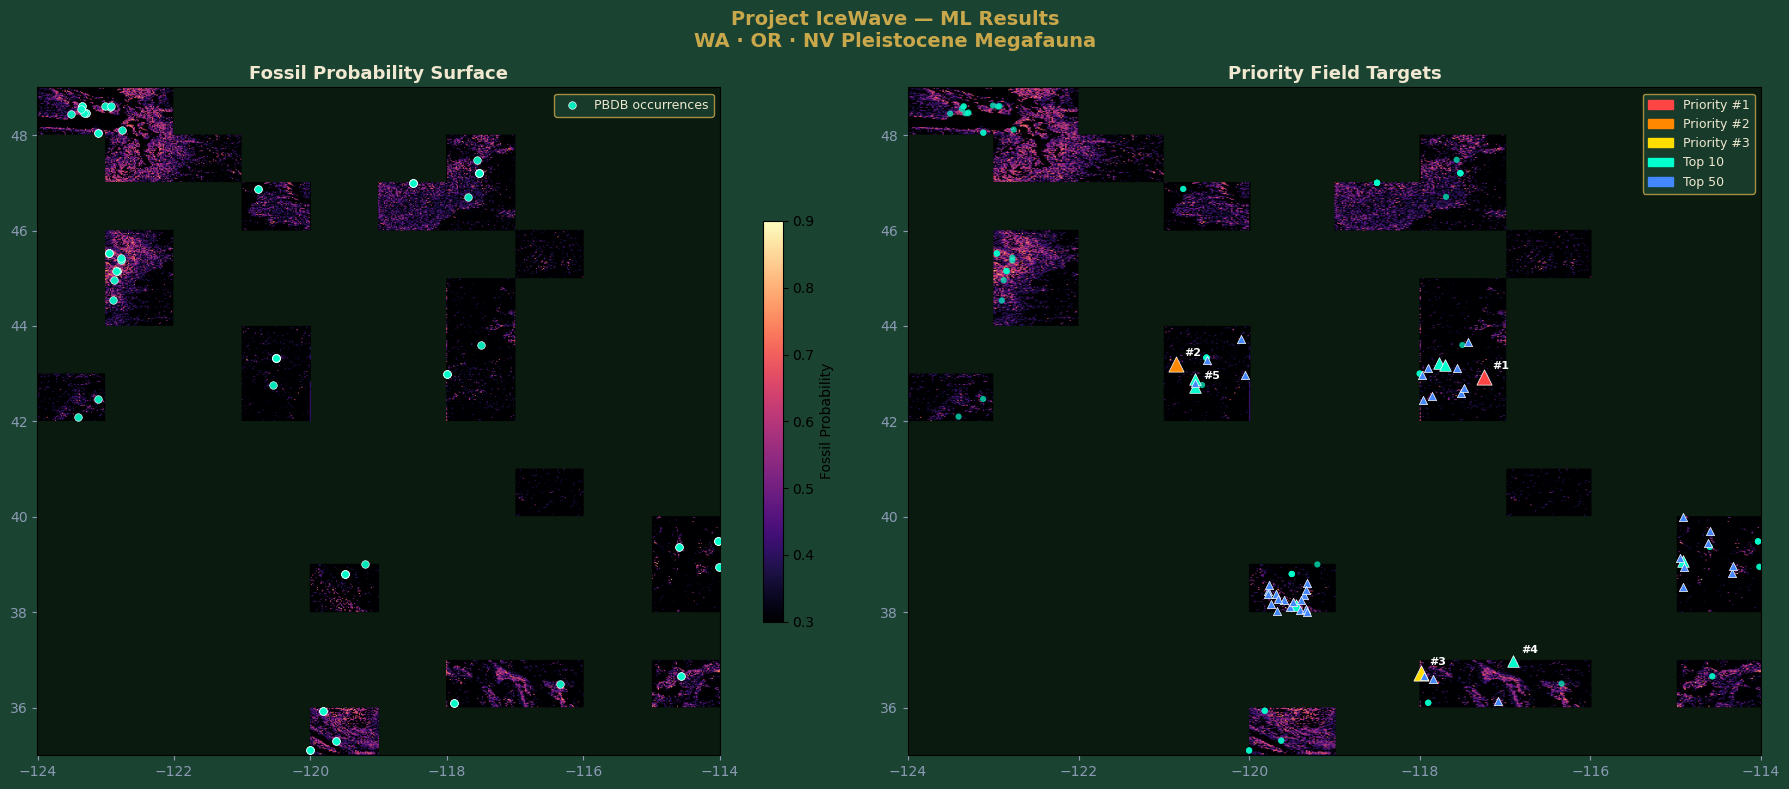

Map saved: outputs/prediction_map.png


In [27]:
# ── Results visualization ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#1b4332')

# Left — prediction surface
ax1 = axes[0]
ax1.set_facecolor('#0a1a0f')
with rasterio.open(pred_path) as src:
    step = max(1, src.height // 800)
    data = src.read(1, out_shape=(src.height//step, src.width//step))
    data = np.where(data <= 0, np.nan, data)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
im = ax1.imshow(data, cmap='magma', vmin=0.3, vmax=0.9,
                extent=extent, origin='upper', aspect='auto')
plt.colorbar(im, ax=ax1, shrink=0.6, label='Fossil Probability')

# Plot PBDB points
occ_loaded = pd.read_csv('../data/pbdb/icewave_occurrences.csv')
ax1.scatter(occ_loaded['longitude'], occ_loaded['latitude'],
            c='#00ffcc', s=30, zorder=5, alpha=0.9,
            edgecolors='white', linewidths=0.5, label='PBDB occurrences')
ax1.set_title('Fossil Probability Surface', color='#f0e8d0',
               fontsize=13, fontweight='bold')
ax1.legend(facecolor='#1b4332', edgecolor='#c9a84c',
           labelcolor='#f0e8d0', fontsize=9)
ax1.tick_params(colors='#8b9bb4')

# Right — top candidates
ax2 = axes[1]
ax2.set_facecolor('#0a1a0f')
im2 = ax2.imshow(data, cmap='magma', vmin=0.3, vmax=0.9,
                 extent=extent, origin='upper', aspect='auto')

# Color candidates by priority tier
colors_tier = {1: '#ff4444', 2: '#ff8800', 3: '#ffdd00'}
for _, row in cand_df.iterrows():
    p = row['priority']
    c = colors_tier.get(p, '#00ffcc' if p <= 10 else '#4488ff')
    s = 120 if p <= 3 else (70 if p <= 10 else 35)
    ax2.scatter(row['longitude'], row['latitude'],
                c=c, s=s, zorder=6, marker='^',
                edgecolors='white', linewidths=0.5)
    if p <= 5:
        ax2.annotate(f'#{p}', (row['longitude'], row['latitude']),
                     textcoords='offset points', xytext=(6, 6),
                     fontsize=8, color='white', fontweight='bold')

ax2.scatter(occ_loaded['longitude'], occ_loaded['latitude'],
            c='#00ffcc', s=20, zorder=5, alpha=0.7,
            edgecolors='none', label='PBDB')
ax2.set_title('Priority Field Targets', color='#f0e8d0',
               fontsize=13, fontweight='bold')
ax2.tick_params(colors='#8b9bb4')

patches = [
    mpatches.Patch(color='#ff4444', label='Priority #1'),
    mpatches.Patch(color='#ff8800', label='Priority #2'),
    mpatches.Patch(color='#ffdd00', label='Priority #3'),
    mpatches.Patch(color='#00ffcc', label='Top 10'),
    mpatches.Patch(color='#4488ff', label='Top 50'),
]
ax2.legend(handles=patches, facecolor='#1b4332', edgecolor='#c9a84c',
           labelcolor='#f0e8d0', fontsize=9)

plt.suptitle('Project IceWave — ML Results\nWA · OR · NV Pleistocene Megafauna',
             color='#c9a84c', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/prediction_map.png', dpi=150,
            bbox_inches='tight', facecolor='#1b4332')
plt.show()
print('Map saved: outputs/prediction_map.png')


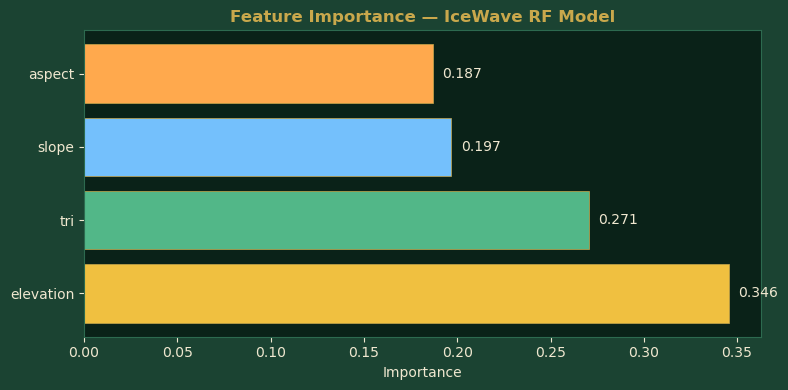

Feature importance plot saved.


In [28]:
# ── Feature importance plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#1b4332')
ax.set_facecolor('#0a2218')

colors = ['#f0c040', '#52b788', '#74c0fc', '#ffa94d']
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color=colors[:len(importance_df)], edgecolor='#c9a84c', linewidth=0.5)
ax.set_xlabel('Importance', color='#f0e8d0')
ax.set_title('Feature Importance — IceWave RF Model',
             color='#c9a84c', fontweight='bold')
ax.tick_params(colors='#f0e8d0')
for spine in ax.spines.values():
    spine.set_edgecolor('#2d6a4f')
for bar, val in zip(bars, importance_df['importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='#f0e8d0', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#1b4332')
plt.show()
print('Feature importance plot saved.')


In [29]:
occ = pd.read_csv('../data/merged/icewave_merged_occurrences.csv')

## Results
- `data/model/icewave_rf_model.joblib` — trained model
- `data/model/prediction_surface.tif` — full probability raster
- `data/model/priority_targets.csv` — ranked field targets
- `data/model/priority_targets.geojson` — targets as GeoJSON
- `outputs/prediction_map.png` — results map
- `outputs/feature_importance.png` — feature importance

**Next:** Build field report PDF + KMZ/GPX outputs
